# HR Screening Fit Benchmark — CV Evaluation System

**Dataset:** `datasets/Resumes/<CATEGORY>/*.pdf` — the public 24-category resume dataset (Accountant, Advocate, ... Teacher).

**Task:** Reproduce the app's real screening use case. Each resume is paired with a job description and sent through the exact same prompt the backend uses (`app/prompts/hr_prompt.py::build_hr_evaluation_prompt`). Every model must return `overall_score` (0-100) and a `recommendation`. We treat this as a **binary fit-screening decision**:

- **Gold = 1 (should proceed)** when the resume's own category matches the job description's category.
- **Gold = 0 (should not proceed)** when the resume is paired with a job description from an unrelated category.

A model's prediction is derived by thresholding its `overall_score` (`predicted = 1` if `overall_score >= SCORE_THRESHOLD` else `0`). This lets us compute Accuracy / Precision / Recall / F1 exactly like a classifier, while still exercising the real end-to-end prompt → JSON → structured report pipeline.

**Models evaluated** (from `backend/app/services/settings_service.py::AVAILABLE_MODELS`):

| Provider | Models |
|---|---|
| OpenAI | `gpt-4o-mini`, `gpt-4o`, `gpt-4.1-mini`, `gpt-4.1` |
| Anthropic | `claude-haiku-4-6`, `claude-sonnet-4-6`, `claude-opus-4-6` |
| xAI | `grok-4` |
| DeepSeek | `deepseek-chat` |

> **This run: xAI + DeepSeek only.** OpenAI and Anthropic quota is currently exhausted, so `ACTIVE_PROVIDERS` (in the config cell) limits the run to **xAI** and **DeepSeek**. All four providers stay defined for the full comparison later — set `ACTIVE_PROVIDERS = list(PROVIDER_MODELS)` to re-enable them. The evaluation is also capped to `MAX_EVAL_SAMPLES = 100` pairs (50 match / 50 mismatch) for a fast, low-cost demo.

**Note:** This notebook is written to be run end-to-end, but has **not been executed** in this session (no real API spend was made while authoring it). Run it locally with valid keys in `backend/.env` (or a local `API_KEY.txt` / `.env` next to this notebook).

## 1. Install dependencies

In [1]:
%pip install -q anthropic openai pypdf pandas matplotlib seaborn scikit-learn tqdm python-dotenv tabulate

Note: you may need to restart the kernel to use updated packages.


## 2. Configuration — API keys, models, benchmark settings

Keys are loaded from `backend/.env` (the same file the FastAPI app uses) if present, then from a local `API_KEY.txt` / `.env`, then from the environment. This avoids duplicating secrets for the notebook.

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Reuse the backend's .env if it exists, then fall back to a notebook-local one.
BACKEND_ENV = Path("../backend/.env")
if BACKEND_ENV.exists():
    load_dotenv(BACKEND_ENV)

if os.path.exists("API_KEY.txt"):
    with open("API_KEY.txt", "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ.setdefault(key.strip(), val.strip())

load_dotenv()  # notebook-local .env, does not override already-set vars

# -- API keys --------------------------------------------------------------
OPENAI_API_KEY    = os.getenv("OPENAI_API_KEY", "")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")
XAI_API_KEY       = os.getenv("XAI_API_KEY", "")
DEEPSEEK_API_KEY  = os.getenv("DEEPSEEK_API_KEY", "")

# -- Models under evaluation, grouped by provider ---------------------------
# Mirrors backend/app/services/settings_service.py::AVAILABLE_MODELS
# All four providers are kept here for a full cross-provider comparison later.
PROVIDER_MODELS = {
    "openai":    ["gpt-4o-mini", "gpt-4o", "gpt-4.1-mini", "gpt-4.1"],
    "anthropic": ["claude-haiku-4-6", "claude-sonnet-4-6", "claude-opus-4-6"],
    "xai":       ["grok-4"],
    "deepseek":  ["deepseek-chat"],
}

# Only these providers are actually called in this run. OpenAI and Anthropic (Claude)
# are left in PROVIDER_MODELS above so a full comparison stays one line away, but their
# quota is currently exhausted (0), so we benchmark with xAI and DeepSeek only.
# To run everything again, set: ACTIVE_PROVIDERS = list(PROVIDER_MODELS)
ACTIVE_PROVIDERS = ["xai", "deepseek"]

ALL_RUNS = [
    (provider, model)
    for provider, models in PROVIDER_MODELS.items()
    if provider in ACTIVE_PROVIDERS
    for model in models
]

# -- Benchmark settings -------------------------------------------------------
DATASET_DIR           = Path("datasets/Resumes")
N_RESUMES_PER_CATEGORY = 5        # sampled per category; oversampled so the 100-pair cap is reachable
MAX_EVAL_SAMPLES       = 100      # hard cap on total evaluation pairs (kept 50/50 match/mismatch)
MAX_CV_CHARS           = 6000     # truncate long CVs to keep prompts/costs bounded
SCORE_THRESHOLD        = 60       # overall_score >= threshold -> predicted "should proceed"
MAX_OUTPUT_TOKENS      = 1200
TEMPERATURE            = 0.2
REQUEST_TIMEOUT        = 60       # seconds per request
MAX_RETRIES            = 3        # retries on rate limit / transient errors
RETRY_BASE_DELAY       = 5        # seconds, exponential backoff
RANDOM_SEED            = 42

# -- Output locations (reuses the repo's existing notebooks/outputs & notebooks/reports dirs) --
PLOTS_DIR   = Path("outputs/plots")
RAW_DIR     = Path("outputs/raw")
REPORTS_DIR = Path("reports")
for d in (PLOTS_DIR, RAW_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")
print(f"OpenAI key set: {bool(OPENAI_API_KEY)} | Anthropic key set: {bool(ANTHROPIC_API_KEY)} | "
      f"xAI key set: {bool(XAI_API_KEY)} | DeepSeek key set: {bool(DEEPSEEK_API_KEY)}")
print(f"Active providers this run: {ACTIVE_PROVIDERS}")
print(f"Models under test: {ALL_RUNS}")

Configuration loaded.
OpenAI key set: True | Anthropic key set: True | xAI key set: True | DeepSeek key set: True
Active providers this run: ['xai', 'deepseek']
Models under test: [('xai', 'grok-4'), ('deepseek', 'deepseek-chat')]


## 3. Load & sample the resume dataset

The dataset is organised as `datasets/Resumes/<CATEGORY>/<id>.pdf`. We take a stratified sample so every job category is represented.

In [3]:
import random
import pandas as pd

random.seed(RANDOM_SEED)

categories = sorted([p.name for p in DATASET_DIR.iterdir() if p.is_dir()])
print(f"Found {len(categories)} categories: {categories}")

sampled_rows = []
for category in categories:
    pdfs = sorted((DATASET_DIR / category).glob("*.pdf"))
    if not pdfs:
        continue
    picks = random.sample(pdfs, k=min(N_RESUMES_PER_CATEGORY, len(pdfs)))
    for p in picks:
        sampled_rows.append({"resume_id": p.stem, "category": category, "pdf_path": str(p)})

df_resumes = pd.DataFrame(sampled_rows)
print(f"Sampled {len(df_resumes)} resumes across {df_resumes['category'].nunique()} categories")
df_resumes.head(10)

Found 24 categories: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
Sampled 120 resumes across 24 categories


,resume_id,category,pdf_path
0,28939941,ACCOUNTANT,datasets\Resumes\ACCOUNTANT\28939941.pdf
1,13701259,ACCOUNTANT,datasets\Resumes\ACCOUNTANT\13701259.pdf
2,11759079,ACCOUNTANT,datasets\Resumes\ACCOUNTANT\11759079.pdf
3,35554162,ACCOUNTANT,datasets\Resumes\ACCOUNTANT\35554162.pdf
4,18669563,ACCOUNTANT,datasets\Resumes\ACCOUNTANT\18669563.pdf
5,17911230,ADVOCATE,datasets\Resumes\ADVOCATE\17911230.pdf
6,17165107,ADVOCATE,datasets\Resumes\ADVOCATE\17165107.pdf
7,14064815,ADVOCATE,datasets\Resumes\ADVOCATE\14064815.pdf
8,44115326,ADVOCATE,datasets\Resumes\ADVOCATE\44115326.pdf
9,13593241,ADVOCATE,datasets\Resumes\ADVOCATE\13593241.pdf


## 4. Extract CV text from PDFs

Mirrors `backend/app/services/parser/pdf_parser.py::extract_pdf_text` — extract text per page with `pypdf` and join with newlines. Image-only PDFs (no extractable text) are dropped, same as the backend rejecting them.

In [4]:
from pypdf import PdfReader


def extract_pdf_text(path: str) -> str:
    """Extract text from a PDF the same way the backend does (pypdf, per-page, joined by \\n)."""
    reader = PdfReader(path)
    pages = [page.extract_text() or "" for page in reader.pages]
    return "\n".join(pages).strip()


def extract_safe(path: str) -> str:
    try:
        return extract_pdf_text(path)
    except Exception as e:
        print(f"[extract] failed for {path}: {e}")
        return ""


df_resumes["cv_text"] = df_resumes["pdf_path"].apply(extract_safe)
df_resumes["cv_text"] = df_resumes["cv_text"].str.slice(0, MAX_CV_CHARS)

before = len(df_resumes)
df_resumes = df_resumes[df_resumes["cv_text"].str.len() > 50].reset_index(drop=True)
print(f"Dropped {before - len(df_resumes)} resumes with no extractable text (image-only PDFs).")
print(f"Remaining: {len(df_resumes)} resumes. Avg CV length: {df_resumes['cv_text'].str.len().mean():.0f} chars")

Dropped 1 resumes with no extractable text (image-only PDFs).
Remaining: 119 resumes. Avg CV length: 5442 chars


## 5. Build job descriptions & match / mismatch evaluation pairs

Each resume is evaluated twice:
- **match**: paired with the job description of its *own* category → gold label `1` (should proceed).
- **mismatch**: paired with a job description from a *different, randomly chosen* category → gold label `0` (should not proceed).

This gives a balanced binary ground truth without needing hand-labelled fit scores.

In [5]:
# --- Cap the evaluation set for a fast, low-cost run -------------------------
# Each resume yields 2 pairs (1 match + 1 mismatch), so keeping MAX_EVAL_SAMPLES // 2
# resumes gives at most MAX_EVAL_SAMPLES pairs while preserving the 50/50 label balance.
random.seed(RANDOM_SEED)  # reproducible trim + mismatch pairing in the next cell
_max_resumes = MAX_EVAL_SAMPLES // 2
if len(df_resumes) > _max_resumes:
    df_resumes = df_resumes.sample(n=_max_resumes, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Using {len(df_resumes)} resumes -> up to {len(df_resumes) * 2} evaluation pairs "
      f"(MAX_EVAL_SAMPLES={MAX_EVAL_SAMPLES}).")

Using 50 resumes -> up to 100 evaluation pairs (MAX_EVAL_SAMPLES=100).


In [6]:
JOB_DESCRIPTIONS = {
    "ACCOUNTANT": "Kami mencari Akuntan untuk mengelola pembukuan, menyusun laporan keuangan bulanan, memastikan kepatuhan pajak, dan melakukan rekonsiliasi anggaran. Diutamakan yang memiliki pengalaman audit dan menguasai software akuntansi.",
    "ADVOCATE": "Kami mencari Advokat untuk menangani litigasi, memberikan nasihat hukum kepada klien, menyusun kontrak, dan mewakili perusahaan dalam persidangan. Diutamakan memiliki izin praktik dan pengalaman hukum korporat.",
    "AGRICULTURE": "Kami mencari staf Pertanian untuk mengelola operasional lahan, riset hasil panen, penerapan teknik budidaya modern, dan koordinasi dengan petani mitra.",
    "APPAREL": "Kami mencari staf industri Apparel/Garmen untuk mengelola produksi pakaian, quality control, koordinasi dengan pemasok kain, dan perencanaan lini produksi.",
    "ARTS": "Kami mencari profesional Seni untuk proyek kreatif, desain visual, kurasi pameran, dan kolaborasi dengan tim kreatif lain.",
    "AUTOMOBILE": "Kami mencari staf Otomotif untuk perawatan dan perbaikan kendaraan, manajemen suku cadang, serta layanan purna jual pelanggan.",
    "AVIATION": "Kami mencari staf Aviasi untuk operasional bandara, keselamatan penerbangan, koordinasi kru, atau layanan pelanggan maskapai.",
    "BANKING": "Kami mencari staf Perbankan untuk layanan nasabah, analisis kredit, manajemen produk perbankan, dan kepatuhan regulasi keuangan.",
    "BPO": "Kami mencari staf BPO/Call Center untuk menangani layanan pelanggan, penyelesaian keluhan, dan pencapaian target layanan (SLA).",
    "BUSINESS-DEVELOPMENT": "Kami mencari staf Business Development untuk mencari peluang bisnis baru, membangun kemitraan strategis, dan menyusun strategi pertumbuhan perusahaan.",
    "CHEF": "Kami mencari Chef untuk mengelola dapur, menyusun menu, memastikan standar kebersihan makanan, dan memimpin tim kuliner.",
    "CONSTRUCTION": "Kami mencari staf Konstruksi untuk mengawasi proyek pembangunan, manajemen material, keselamatan kerja lapangan, dan koordinasi kontraktor.",
    "CONSULTANT": "Kami mencari Konsultan untuk memberikan rekomendasi strategis kepada klien, analisis bisnis, dan penyusunan laporan proyek.",
    "DESIGNER": "Kami mencari Desainer untuk merancang materi visual/produk, bekerja dengan software desain, dan berkolaborasi dengan tim produk/marketing.",
    "DIGITAL-MEDIA": "Kami mencari staf Digital Media untuk mengelola konten media sosial, strategi pemasaran digital, dan analisis performa kampanye online.",
    "ENGINEERING": "Kami mencari Engineer untuk merancang, menguji, dan memelihara sistem/produk teknis sesuai standar industri dan spesifikasi proyek.",
    "FINANCE": "Kami mencari staf Finance untuk analisis keuangan, penyusunan anggaran, forecasting, dan pelaporan kinerja finansial perusahaan.",
    "FITNESS": "Kami mencari Pelatih Kebugaran untuk menyusun program latihan, membina member gym, dan memastikan keselamatan sesi latihan.",
    "HEALTHCARE": "Kami mencari staf Kesehatan untuk memberikan layanan medis/perawatan pasien sesuai standar dan prosedur kesehatan.",
    "HR": "Kami mencari staf HR untuk rekrutmen, manajemen talenta, administrasi kepegawaian, dan pengembangan budaya kerja.",
    "INFORMATION-TECHNOLOGY": "Kami mencari staf IT untuk pengembangan software, administrasi sistem, dukungan teknis, dan keamanan infrastruktur TI.",
    "PUBLIC-RELATIONS": "Kami mencari staf Public Relations untuk mengelola komunikasi publik, hubungan media, dan strategi reputasi perusahaan.",
    "SALES": "Kami mencari staf Sales untuk mencapai target penjualan, membina hubungan klien, dan menyusun strategi penjualan produk/jasa.",
    "TEACHER": "Kami mencari Guru untuk mengajar dan menyusun materi pembelajaran, menilai perkembangan siswa, serta membina kelas secara efektif.",
}

missing = [c for c in categories if c not in JOB_DESCRIPTIONS]
assert not missing, f"Missing job descriptions for: {missing}"

pair_rows = []
for _, r in df_resumes.iterrows():
    # match: own category
    pair_rows.append({
        "resume_id": r["resume_id"], "category": r["category"], "cv_text": r["cv_text"],
        "pairing": "match", "job_category": r["category"],
        "job_description": JOB_DESCRIPTIONS[r["category"]], "gold_label": 1,
    })
    # mismatch: a different, randomly chosen category
    other_categories = [c for c in categories if c != r["category"]]
    mismatch_category = random.choice(other_categories)
    pair_rows.append({
        "resume_id": r["resume_id"], "category": r["category"], "cv_text": r["cv_text"],
        "pairing": "mismatch", "job_category": mismatch_category,
        "job_description": JOB_DESCRIPTIONS[mismatch_category], "gold_label": 0,
    })

df_pairs = pd.DataFrame(pair_rows)
print(f"Built {len(df_pairs)} evaluation pairs ({len(df_pairs) // 2} resumes x 2 pairings)")
print(df_pairs["gold_label"].value_counts())
df_pairs.head(6)

Built 100 evaluation pairs (50 resumes x 2 pairings)
gold_label
1    50
0    50
Name: count, dtype: int64


,resume_id,category,cv_text,pairing,job_category,job_description,gold_label
0,10734870,CONSTRUCTION,CONSTRUCTION\nSummary\nThe purpose of submitti...,match,CONSTRUCTION,Kami mencari staf Konstruksi untuk mengawasi p...,1
1,10734870,CONSTRUCTION,CONSTRUCTION\nSummary\nThe purpose of submitti...,mismatch,PUBLIC-RELATIONS,Kami mencari staf Public Relations untuk menge...,0
2,15636923,HEALTHCARE,CERTIFIED PERSONAL TRAINER\nProfessional Summa...,match,HEALTHCARE,Kami mencari staf Kesehatan untuk memberikan l...,1
3,15636923,HEALTHCARE,CERTIFIED PERSONAL TRAINER\nProfessional Summa...,mismatch,APPAREL,Kami mencari staf industri Apparel/Garmen untu...,0
4,18669563,ACCOUNTANT,PROJECT ACCOUNTANT\nProfessional Summary\nObta...,match,ACCOUNTANT,Kami mencari Akuntan untuk mengelola pembukuan...,1
5,18669563,ACCOUNTANT,PROJECT ACCOUNTANT\nProfessional Summary\nObta...,mismatch,ADVOCATE,"Kami mencari Advokat untuk menangani litigasi,...",0


## 6. Prompt template — verbatim from the backend

Copied from `backend/app/prompts/hr_prompt.py::build_hr_evaluation_prompt` so every model is tested against the exact prompt the production app sends.

In [7]:
def build_hr_evaluation_prompt(job_description: str, cv_text: str) -> str:
    return f"""Anda membantu staf HR menilai apakah kandidat cocok untuk lowongan tertentu.

Tulis seluruh isi jawaban dalam Bahasa Indonesia yang jelas, singkat, dan mudah dipahami staf HR.
Hindari istilah teknis AI. Jangan membuat klaim yang tidak didukung oleh CV atau deskripsi lowongan.
Nilai kandidat berdasarkan kecocokan terhadap deskripsi lowongan, bukan berdasarkan kualitas CV secara umum.

Kembalikan hanya JSON valid dengan bentuk berikut:
{{
  "overall_score": 0,
  "summary": "",
  "strengths": [],
  "weaknesses": [],
  "skills": [
    {{
      "name": "",
      "score": 0,
      "evidence": ""
    }}
  ],
  "recommendation": ""
}}

Aturan isi:
- overall_score adalah skor kecocokan kandidat dengan lowongan dari 0 sampai 100.
- summary berisi 2 sampai 4 paragraf pendek dari sudut pandang HR.
- strengths berisi 3 sampai 5 kelebihan kandidat yang relevan dengan lowongan.
- weaknesses berisi 2 sampai 5 hal yang perlu diperhatikan sebelum lanjut proses.
- skills berisi kemampuan atau kriteria utama yang relevan dengan lowongan, beserta bukti singkat dari CV.
- recommendation harus langsung menjawab apakah HR sebaiknya melanjutkan proses rekrutmen.

Deskripsi lowongan:
{job_description}

Teks CV kandidat:
{cv_text}"""


print(build_hr_evaluation_prompt(JOB_DESCRIPTIONS["ACCOUNTANT"], "Contoh isi CV...")[:400] + "...")

Anda membantu staf HR menilai apakah kandidat cocok untuk lowongan tertentu.

Tulis seluruh isi jawaban dalam Bahasa Indonesia yang jelas, singkat, dan mudah dipahami staf HR.
Hindari istilah teknis AI. Jangan membuat klaim yang tidak didukung oleh CV atau deskripsi lowongan.
Nilai kandidat berdasarkan kecocokan terhadap deskripsi lowongan, bukan berdasarkan kualitas CV secara umum.

Kembalikan ha...


## 7. API client helpers — call model, parse JSON, retry on errors

- OpenAI, xAI & DeepSeek use the OpenAI SDK (xAI via its OpenAI-compatible `base_url=https://api.x.ai/v1`, DeepSeek via `base_url=https://api.deepseek.com/v1`), JSON mode when available — matches `backend/app/services/ai/openai_service.py`, `xai_service.py`, and `deepseek_service.py`.
- Anthropic uses plain-text messages and the JSON is parsed out of the response text — matches `backend/app/services/ai/claude_service.py` (no system prompt param; everything is in the single user message).
- `parse_json_object` mirrors `backend/app/services/ai/json_parser.py`: strips markdown code fences before `json.loads`.
- `call_with_retries` adds exponential backoff so transient rate-limit/timeout errors don't kill the whole benchmark run.

In [8]:
import json
import re
import time

import anthropic
import openai

_openai_client    = openai.OpenAI(api_key=OPENAI_API_KEY, timeout=REQUEST_TIMEOUT)
_xai_client       = openai.OpenAI(api_key=XAI_API_KEY, base_url="https://api.x.ai/v1", timeout=REQUEST_TIMEOUT)
_deepseek_client  = openai.OpenAI(api_key=DEEPSEEK_API_KEY, base_url="https://api.deepseek.com/v1", timeout=REQUEST_TIMEOUT)
_anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY, timeout=REQUEST_TIMEOUT)

_FENCE_RE = re.compile(r"^```(?:json)?\s*|\s*```$", re.MULTILINE)


def parse_json_object(raw: str):
    """Best-effort JSON parse of a model reply. Returns None on failure (never raises)."""
    if not raw:
        return None
    cleaned = _FENCE_RE.sub("", raw.strip())
    try:
        obj = json.loads(cleaned)
        return obj if isinstance(obj, dict) else None
    except json.JSONDecodeError:
        return None


def call_with_retries(fn, *args, max_retries=MAX_RETRIES, base_delay=RETRY_BASE_DELAY, **kwargs):
    """Run fn(*args, **kwargs), retrying with exponential backoff on rate-limit/timeout/connection errors."""
    last_exc = None
    for attempt in range(max_retries + 1):
        try:
            return fn(*args, **kwargs)
        except (openai.RateLimitError, openai.APITimeoutError, openai.APIConnectionError,
                anthropic.RateLimitError, anthropic.APITimeoutError, anthropic.APIConnectionError) as e:
            last_exc = e
            if attempt < max_retries:
                delay = base_delay * (2 ** attempt)
                print(f"  [retry] {type(e).__name__} — waiting {delay}s (attempt {attempt + 1}/{max_retries})")
                time.sleep(delay)
    raise last_exc


def _chat_openai_compatible(client, model, prompt, json_mode=True):
    kwargs = dict(
        model=model,
        max_tokens=MAX_OUTPUT_TOKENS,
        temperature=TEMPERATURE,
        messages=[{"role": "user", "content": prompt}],
    )
    if json_mode:
        kwargs["response_format"] = {"type": "json_object"}
    resp = client.chat.completions.create(**kwargs)
    return {
        "raw": resp.choices[0].message.content or "",
        "input_tokens": resp.usage.prompt_tokens,
        "output_tokens": resp.usage.completion_tokens,
    }


def call_openai(model, prompt):
    return call_with_retries(_chat_openai_compatible, _openai_client, model, prompt, json_mode=True)


def call_xai(model, prompt):
    # Some xAI models reject response_format=json_object; fall back to plain mode on that specific error.
    try:
        return call_with_retries(_chat_openai_compatible, _xai_client, model, prompt, json_mode=True)
    except openai.BadRequestError:
        return call_with_retries(_chat_openai_compatible, _xai_client, model, prompt, json_mode=False)


def call_deepseek(model, prompt):
    # DeepSeek is OpenAI-compatible (base_url https://api.deepseek.com/v1) and deepseek-chat supports
    # JSON output mode; fall back to plain mode if a model/endpoint rejects response_format.
    try:
        return call_with_retries(_chat_openai_compatible, _deepseek_client, model, prompt, json_mode=True)
    except openai.BadRequestError:
        return call_with_retries(_chat_openai_compatible, _deepseek_client, model, prompt, json_mode=False)


def _chat_anthropic(model, prompt):
    msg = _anthropic_client.messages.create(
        model=model,
        max_tokens=MAX_OUTPUT_TOKENS,
        temperature=TEMPERATURE,
        messages=[{"role": "user", "content": prompt}],
    )
    raw = "".join(b.text for b in msg.content if getattr(b, "type", None) == "text")
    return {
        "raw": raw,
        "input_tokens": msg.usage.input_tokens,
        "output_tokens": msg.usage.output_tokens,
    }


def call_anthropic(model, prompt):
    return call_with_retries(_chat_anthropic, model, prompt)


PROVIDER_CALLERS = {
    "openai": call_openai,
    "anthropic": call_anthropic,
    "xai": call_xai,
    "deepseek": call_deepseek,
}

print("API helpers ready.")

API helpers ready.


## 8. Evaluate one (model, resume/job pair) — score → predicted label

In [9]:
def evaluate_one(provider: str, model: str, job_description: str, cv_text: str) -> dict:
    """Call one model on one (job_description, cv_text) pair. Never raises — errors are captured in the result."""
    prompt = build_hr_evaluation_prompt(job_description, cv_text)
    t0 = time.perf_counter()
    try:
        resp = PROVIDER_CALLERS[provider](model, prompt)
    except Exception as e:
        return {
            "raw": "", "overall_score": None, "recommendation": "",
            "predicted_label": 0, "parse_error": True, "api_error": str(e),
            "latency_s": time.perf_counter() - t0, "input_tokens": 0, "output_tokens": 0,
        }

    latency = time.perf_counter() - t0
    report = parse_json_object(resp["raw"])
    overall_score = None
    recommendation = ""
    parse_error = report is None

    if report is not None:
        try:
            overall_score = int(report.get("overall_score"))
        except (TypeError, ValueError):
            overall_score = None
        recommendation = str(report.get("recommendation", ""))

    predicted_label = 1 if (overall_score is not None and overall_score >= SCORE_THRESHOLD) else 0

    return {
        "raw": resp["raw"], "overall_score": overall_score, "recommendation": recommendation,
        "predicted_label": predicted_label, "parse_error": parse_error, "api_error": None,
        "latency_s": latency, "input_tokens": resp["input_tokens"], "output_tokens": resp["output_tokens"],
    }

## 9. Run the benchmark

Every evaluation pair is sent to every model. Failures (rate limits, timeouts, malformed JSON) are logged and recorded as a wrong prediction rather than halting the run.

In [10]:
from tqdm.notebook import tqdm

records = []
total = len(df_pairs) * len(ALL_RUNS)

with tqdm(total=total, desc="Evaluations") as pbar:
    for provider, model in ALL_RUNS:
        for _, row in df_pairs.iterrows():
            result = evaluate_one(provider, model, row["job_description"], row["cv_text"])
            records.append({
                "provider": provider, "model": model,
                "resume_id": row["resume_id"], "category": row["category"],
                "pairing": row["pairing"], "job_category": row["job_category"],
                "gold_label": row["gold_label"], **result,
            })
            if result["api_error"]:
                print(f"[{provider}/{model}] {row['resume_id']} ({row['pairing']}) failed: {result['api_error']}")
            pbar.update(1)

df_results = pd.DataFrame(records)
df_results["total_tokens"] = df_results["input_tokens"] + df_results["output_tokens"]
print(f"Collected {len(df_results)} results "
      f"({df_results['api_error'].notna().sum()} API errors, {df_results['parse_error'].sum()} JSON parse errors)")

df_results.to_csv(RAW_DIR / "hr_eval_raw.csv", index=False)
df_results.head(8)

Evaluations:   0%|          | 0/200 [00:00<?, ?it/s]

Collected 200 results (0 API errors, 0 JSON parse errors)


,provider,model,resume_id,category,pairing,job_category,gold_label,raw,overall_score,recommendation,predicted_label,parse_error,api_error,latency_s,input_tokens,output_tokens,total_tokens
0,xai,grok-4,10734870,CONSTRUCTION,match,CONSTRUCTION,1,"{\n ""overall_score"": 45,\n ""summary"": ""Kandi...",45,Tidak disarankan melanjutkan proses rekrutmen ...,0,False,None,10.190471,1672,655,2327
1,xai,grok-4,10734870,CONSTRUCTION,mismatch,PUBLIC-RELATIONS,0,"{\n ""overall_score"": 25,\n ""summary"": ""Kandi...",25,Tidak merekomendasikan untuk melanjutkan prose...,0,False,None,9.327259,1660,548,2208
2,xai,grok-4,15636923,HEALTHCARE,match,HEALTHCARE,1,"{\n ""overall_score"": 65,\n ""summary"": ""Kandi...",65,"Ya, HR sebaiknya melanjutkan proses rekrutmen ...",1,False,None,10.237351,1605,657,2262
3,xai,grok-4,15636923,HEALTHCARE,mismatch,APPAREL,0,"{\n ""overall_score"": 15,\n ""summary"": ""Kandi...",15,Tidak disarankan untuk melanjutkan proses rekr...,0,False,None,8.138080,1616,473,2089
4,xai,grok-4,18669563,ACCOUNTANT,match,ACCOUNTANT,1,"{\n ""overall_score"": 65,\n ""summary"": ""Kandi...",65,"Ya, lanjutkan proses rekrutmen untuk wawancara...",1,False,None,19.080498,1449,484,1933
5,xai,grok-4,18669563,ACCOUNTANT,mismatch,ADVOCATE,0,"{\n ""overall_score"": 0,\n ""summary"": ""Kandid...",0,Tidak melanjutkan proses rekrutmen karena tida...,0,False,None,12.344768,1441,436,1877
6,xai,grok-4,37391947,BUSINESS-DEVELOPMENT,match,BUSINESS-DEVELOPMENT,1,"{\n ""overall_score"": 25,\n ""summary"": ""Kandi...",25,Tidak merekomendasikan untuk melanjutkan prose...,0,False,None,10.808930,1718,530,2248
7,xai,grok-4,37391947,BUSINESS-DEVELOPMENT,mismatch,BPO,0,"{\n ""overall_score"": 60,\n ""summary"": ""Kandi...",60,Disarankan untuk melanjutkan proses rekrutmen ...,1,False,None,10.778903,1720,501,2221


## 10. Classification quality — Accuracy, Precision, Recall, F1

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

quality_rows = []
for (provider, model), grp in df_results.groupby(["provider", "model"], sort=False):
    y_true = grp["gold_label"].tolist()
    y_pred = grp["predicted_label"].tolist()
    quality_rows.append({
        "provider": provider, "model": model,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "F1":        round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        "avg_latency_s": round(grp["latency_s"].mean(), 3),
        "avg_score":     round(grp["overall_score"].dropna().mean(), 1) if grp["overall_score"].notna().any() else None,
        "parse_errors":  int(grp["parse_error"].sum()),
    })

df_quality = pd.DataFrame(quality_rows).set_index("model")
df_quality

,provider,Accuracy,Precision,Recall,F1,avg_latency_s,avg_score,parse_errors
model,,,,,,,,
grok-4,xai,0.72,0.8235,0.56,0.6667,12.453,39.3,0
deepseek-chat,deepseek,0.71,0.8387,0.52,0.6420,5.573,39.0,0


## 11. Provider-level comparison — models within each provider

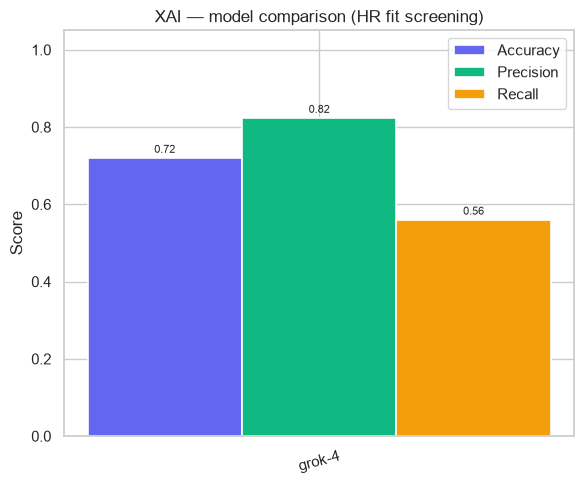

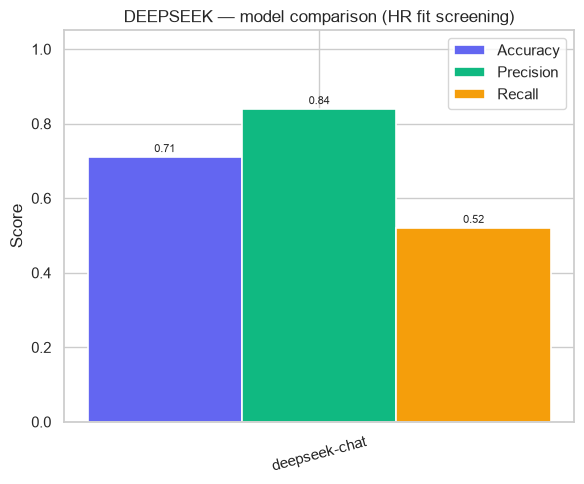

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
METRICS = ["Accuracy", "Precision", "Recall"]
METRIC_COLORS = {"Accuracy": "#6366f1", "Precision": "#10b981", "Recall": "#f59e0b"}

for provider in PROVIDER_MODELS:
    sub = df_quality[df_quality["provider"] == provider]
    if sub.empty:
        continue
    models = list(sub.index)
    x = range(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, 2 * len(models)), 5))
    for i, metric in enumerate(METRICS):
        offsets = [xi + (i - 1) * width for xi in x]
        bars = ax.bar(offsets, sub[metric], width=width, label=metric, color=METRIC_COLORS[metric],
                       edgecolor="white", linewidth=1.2)
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)

    ax.set_xticks(list(x))
    ax.set_xticklabels(models, rotation=15)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{provider.upper()} — model comparison (HR fit screening)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"provider_{provider}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 12. Cross-provider comparison — best model per provider

In [13]:
best_per_provider = (
    df_quality.reset_index()
    .sort_values("F1", ascending=False)
    .groupby("provider", sort=False)
    .first()
    .reset_index()
    .set_index("model")
)
print("Best model per provider (by F1):")
best_per_provider[["provider", "Accuracy", "Precision", "Recall", "F1"]]

Best model per provider (by F1):


,provider,Accuracy,Precision,Recall,F1
model,,,,,
grok-4,xai,0.72,0.8235,0.56,0.6667
deepseek-chat,deepseek,0.71,0.8387,0.52,0.6420


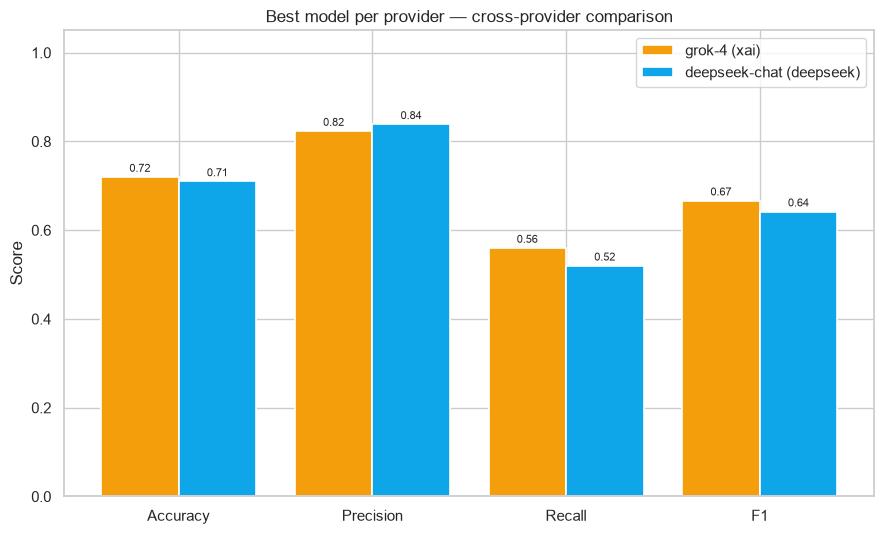

In [14]:
CROSS_METRICS = ["Accuracy", "Precision", "Recall", "F1"]
PROVIDER_COLORS = {"openai": "#10b981", "anthropic": "#6366f1", "xai": "#f59e0b", "deepseek": "#0ea5e9"}

models_best = list(best_per_provider.index)
colors_best = [PROVIDER_COLORS[best_per_provider.loc[m, "provider"]] for m in models_best]
x = range(len(CROSS_METRICS))
width = 0.8 / len(models_best)

fig, ax = plt.subplots(figsize=(9, 5.5))
for i, model in enumerate(models_best):
    offsets = [xi + (i - (len(models_best) - 1) / 2) * width for xi in x]
    vals = [best_per_provider.loc[model, m] for m in CROSS_METRICS]
    bars = ax.bar(offsets, vals, width=width, label=f"{model} ({best_per_provider.loc[model, 'provider']})",
                   color=colors_best[i], edgecolor="white", linewidth=1.2)
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)

ax.set_xticks(list(x))
ax.set_xticklabels(CROSS_METRICS)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Best model per provider — cross-provider comparison")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cross_provider_best.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Confusion matrices for the 3 finalists

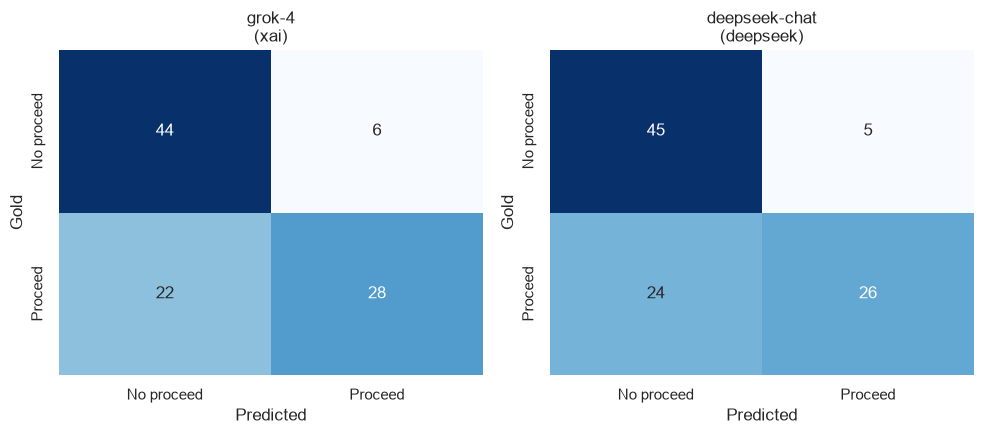

In [15]:
fig, axes = plt.subplots(1, len(models_best), figsize=(5 * len(models_best), 4.5))
if len(models_best) == 1:
    axes = [axes]
for ax, model in zip(axes, models_best):
    grp = df_results[df_results["model"] == model]
    cm = confusion_matrix(grp["gold_label"], grp["predicted_label"], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["No proceed", "Proceed"], yticklabels=["No proceed", "Proceed"], ax=ax)
    ax.set_title(f"{model}\n({best_per_provider.loc[model, 'provider']})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Gold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cross_provider_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Save summary results

In [16]:
summary_cols = ["provider", "Accuracy", "Precision", "Recall", "F1", "avg_latency_s", "avg_score", "parse_errors"]
df_summary = df_quality[summary_cols].sort_values("F1", ascending=False)

df_summary.to_csv(REPORTS_DIR / "hr_eval_summary.csv")
with open(REPORTS_DIR / "hr_eval_summary.md", "w", encoding="utf-8") as f:
    f.write("# HR Screening Fit Benchmark — Summary\n\n")
    f.write(df_summary.to_markdown())
    f.write("\n\n## Best model per provider\n\n")
    f.write(best_per_provider[["provider", "Accuracy", "Precision", "Recall", "F1"]].to_markdown())
    f.write("\n")

print(f"Saved: {REPORTS_DIR / 'hr_eval_summary.csv'}")
print(f"Saved: {REPORTS_DIR / 'hr_eval_summary.md'}")
df_summary

Saved: reports\hr_eval_summary.csv
Saved: reports\hr_eval_summary.md


,provider,Accuracy,Precision,Recall,F1,avg_latency_s,avg_score,parse_errors
model,,,,,,,,
grok-4,xai,0.72,0.8235,0.56,0.6667,12.453,39.3,0
deepseek-chat,deepseek,0.71,0.8387,0.52,0.6420,5.573,39.0,0


## 15. Final leaderboard

In [17]:
leaderboard = df_summary.copy()
leaderboard.columns = ["Provider", "Accuracy", "Precision", "Recall", "F1", "Avg Lat(s)", "Avg Score", "Parse Errors"]

display(
    leaderboard.style
    .background_gradient(subset=["Accuracy", "Precision", "Recall", "F1"], cmap="Greens")
    .background_gradient(subset=["Avg Lat(s)"], cmap="Reds_r")
    .format(precision=3)
)

,Provider,Accuracy,Precision,Recall,F1,Avg Lat(s),Avg Score,Parse Errors
model,,,,,,,,
grok-4,xai,0.720,0.824,0.560,0.667,12.453,39.300,0
deepseek-chat,deepseek,0.710,0.839,0.520,0.642,5.573,39.000,0


---
### Metric guide

| Metric | Direction | Notes |
|--------|-----------|-------|
| **Accuracy** | ↑ higher is better | Fraction of match/mismatch pairs the model screened correctly |
| **Precision** | ↑ higher is better | Of the pairs a model said "proceed", how many were actually a real category match |
| **Recall** | ↑ higher is better | Of the real category matches, how many the model correctly said "proceed" on |
| **F1** | ↑ higher is better | Harmonic mean of precision & recall |
| **avg_score** | context only | Mean `overall_score` returned by the model, for sanity-checking the `SCORE_THRESHOLD` |
| **parse_errors** | ↓ lower is better | Replies that weren't valid JSON — a reliability signal independent of screening quality |

### Next steps / things to try
- Raise `N_RESUMES_PER_CATEGORY` for a more statistically stable comparison (higher cost).
- Tune `SCORE_THRESHOLD` — check `avg_score` per pairing type (`match` vs `mismatch`) to pick a better cut-off than a flat 60.
- Add near-miss job descriptions (adjacent categories, e.g. FINANCE vs ACCOUNTANT) to test finer-grained discrimination instead of only clearly-unrelated mismatches.
- Swap `SCORE_THRESHOLD` thresholding for parsing the free-text `recommendation` field directly, and compare the two labeling strategies.